# Лабораторная — Часть 4: Реализация SimpleYOLO
**4а** Реализация → **4б** Обучение → **4в** Оценка → **4г** vs п.2 → **4д** Выводы → **4е** +п.3 → **4ж** Обучение → **4з** Оценка → **4и** vs п.3 → **4к** Итог

In [24]:
import sys
!{sys.executable} -m pip install "numpy==1.26.4" "opencv-python-headless==4.8.1.78" ultralytics==8.3.0 albumentations -q
import os, math, yaml
from pathlib import Path
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

DEVICE = 0
IMG_SIZE = 416
BATCH = 4
STRIDES = [8, 16, 32]
DATA_YAML = str(Path('data.yaml').absolute())
with open(DATA_YAML) as f: cfg = yaml.safe_load(f)
CLASS_NAMES = cfg['names']
NUM_CLASSES = cfg['nc']
print(f'Классов: {NUM_CLASSES}: {CLASS_NAMES}')

Классов: 13: {0: 'bishop', 1: 'black-bishop', 2: 'black-king', 3: 'black-knight', 4: 'black-pawn', 5: 'black-queen', 6: 'black-rook', 7: 'white-bishop', 8: 'white-king', 9: 'white-knight', 10: 'white-pawn', 11: 'white-queen', 12: 'white-rook'}


In [25]:
# 4а. АРХИТЕКТУРА SimpleYOLO
class CBS(nn.Module):
    def __init__(self, ic, oc, k=3, s=1, p=None):
        super().__init__()
        p = k // 2 if p is None else p
        self.b = nn.Sequential(nn.Conv2d(ic, oc, k, s, p, bias=False), nn.BatchNorm2d(oc), nn.SiLU(True))

    def forward(self, x): return self.b(x)


class Btn(nn.Module):
    def __init__(self, ch):
        super().__init__()
        m = ch // 2
        self.c1 = CBS(ch, m, 3)
        self.c2 = CBS(m, ch, 3)

    def forward(self, x): return x + self.c2(self.c1(x))


class C2f(nn.Module):
    def __init__(self, ic, oc, n=1):
        super().__init__()
        m = oc // 2
        self.cv1 = CBS(ic, oc, 1, p=0)
        self.cv2 = CBS(oc + n * m, oc, 1, p=0)
        self.bns = nn.ModuleList([Btn(m) for _ in range(n)])

    def forward(self, x):
        y = list(self.cv1(x).chunk(2, 1))
        for b in self.bns: y.append(b(y[-1]))
        return self.cv2(torch.cat(y, 1))


class SPPF(nn.Module):
    def __init__(self, ch):
        super().__init__()
        m = ch // 2
        self.cv1 = CBS(ch, m, 1, p=0)
        self.cv2 = CBS(m * 4, ch, 1, p=0)
        self.mp = nn.MaxPool2d(5, 1, 2)

    def forward(self, x):
        x = self.cv1(x)
        p1 = self.mp(x)
        p2 = self.mp(p1)
        p3 = self.mp(p2)
        return self.cv2(torch.cat([x, p1, p2, p3], 1))


class Head(nn.Module):
    def __init__(self, ic, nc):
        super().__init__()
        m = max(ic, 64)
        self.cls = nn.Sequential(CBS(ic, m, 3), CBS(m, m, 3), nn.Conv2d(m, nc, 1))
        self.reg = nn.Sequential(CBS(ic, m, 3), CBS(m, m, 3), nn.Conv2d(m, 4, 1))

    def forward(self, x): return self.cls(x), self.reg(x)


class SimpleYOLO(nn.Module):
    """
    Anchor-free детектор на PyTorch.
    Backbone: ConvBNSiLU + C2f (аналог YOLOv11 C3k2)
    Neck:     FPN top-down
    Head:     Decoupled cls/reg на 3 масштабах (P3/P4/P5)
    Loss:     Focal Loss (cls) + CIoU (bbox)
    """

    def __init__(self, nc=3):
        super().__init__()
        self.s = CBS(3, 32, 3, 2)
        self.s1 = nn.Sequential(CBS(32, 64, 3, 2), C2f(64, 64, 1))
        self.s2 = nn.Sequential(CBS(64, 128, 3, 2), C2f(128, 128, 2))
        self.s3 = nn.Sequential(CBS(128, 256, 3, 2), C2f(256, 256, 2))
        self.s4 = nn.Sequential(CBS(256, 512, 3, 2), C2f(512, 512, 1), SPPF(512))
        self.up = nn.Upsample(scale_factor=2, mode='nearest')
        self.l5 = CBS(512, 256, 1, p=0)
        self.l4 = CBS(256, 256, 1, p=0)
        self.n4 = C2f(512, 256, 1)
        self.n3 = C2f(384, 128, 1)
        self.h3 = Head(128, nc)
        self.h4 = Head(256, nc)
        self.h5 = Head(512, nc)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.s(x)
        x = self.s1(x)
        p3 = self.s2(x)
        p4 = self.s3(p3)
        p5 = self.s4(p4)
        n4 = self.n4(torch.cat([self.up(self.l5(p5)), self.l4(p4)], 1))
        n3 = self.n3(torch.cat([self.up(n4), p3], 1))
        return self.h3(n3), self.h4(n4), self.h5(p5)


_m = SimpleYOLO(NUM_CLASSES)
with torch.no_grad(): _o = _m(torch.randn(1, 3, IMG_SIZE, IMG_SIZE))
print('Forward OK:')
for i, (c, r) in enumerate(_o): print(f'  Scale{i + 1}: cls={tuple(c.shape)} reg={tuple(r.shape)}')
print(f'Параметров: {sum(p.numel() for p in _m.parameters()) / 1e6:.2f}M')
del _m, _o

Forward OK:
  Scale1: cls=(1, 13, 52, 52) reg=(1, 4, 52, 52)
  Scale2: cls=(1, 13, 26, 26) reg=(1, 4, 26, 26)
  Scale3: cls=(1, 13, 13, 13) reg=(1, 4, 13, 13)
Параметров: 17.21M


In [26]:
# DATASET
def make_tf(aug=False, sz=416):
    tf = [A.HorizontalFlip(p=0.5), A.Rotate(limit=10, p=0.5),
          A.RandomBrightnessContrast(p=0.3), A.HueSaturationValue(p=0.3)] if aug else []
    tf += [A.Resize(sz, sz), A.Normalize(mean=[0, 0, 0], std=[1, 1, 1]), ToTensorV2()]
    return A.Compose(tf, bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))


class ChessDS(Dataset):
    def __init__(self, id, ld, sz=416, aug=False):
        self.imgs = sorted(Path(id).glob('*.jpg')) + sorted(Path(id).glob('*.png'))
        self.ld = Path(ld)
        self.tf = make_tf(aug, sz)

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = np.array(Image.open(self.imgs[idx]).convert('RGB'))
        lp = self.ld / (self.imgs[idx].stem + '.txt')
        bbs, labs = [], []
        if lp.exists():
            for ln in lp.read_text().splitlines():
                p = ln.strip().split()
                if len(p) < 5: continue
                cid = int(p[0])
                cx, cy, bw, bh = map(float, p[1:5])
                # Клипируем чтобы bbox не выходил за границы
                bw = min(bw, 1.0)
                bh = min(bh, 1.0)
                cx = min(max(cx, bw/2), 1.0 - bw/2)
                cy = min(max(cy, bh/2), 1.0 - bh/2)
                if bw > 0.001 and bh > 0.001:
                    bbs.append([cx, cy, bw, bh])
                    labs.append(cid)
        t = self.tf(image=img, bboxes=bbs, class_labels=labs)
        it = t['image'].float() / 255.0
        tg = (torch.tensor([[l, *b] for l, b in zip(t['class_labels'], t['bboxes'])], dtype=torch.float32)
              if t['bboxes'] else torch.zeros((0, 5)))
        return it, tg


cf = lambda b: (torch.stack([x[0] for x in b]), [x[1] for x in b])
trd = ChessDS('train/images', 'train/labels', IMG_SIZE)
vad = ChessDS('valid/images', 'valid/labels', IMG_SIZE)
trdl = DataLoader(trd, BATCH, shuffle=True, collate_fn=cf, num_workers=0)
vadl = DataLoader(vad, BATCH, shuffle=False, collate_fn=cf, num_workers=0)
print(f'Train:{len(trd)} Val:{len(vad)}')

Train:606 Val:58


In [27]:
# ПОТЕРИ + ASSIGNMENT
def fl(p, t, g=2., a=0.25):
    bce = F.binary_cross_entropy_with_logits(p, t, reduction='none')
    return (a * (1 - torch.exp(-bce)) ** g * bce).mean()


def ciou(p, t):
    px1, py1, px2, py2 = p[:, 0], p[:, 1], p[:, 2], p[:, 3]
    tx1, ty1, tx2, ty2 = t[:, 0], t[:, 1], t[:, 2], t[:, 3]
    pa = (px2 - px1).clamp(0) * (py2 - py1).clamp(0)
    ta = (tx2 - tx1).clamp(0) * (ty2 - ty1).clamp(0)
    ix1 = torch.max(px1, tx1)
    iy1 = torch.max(py1, ty1)
    ix2 = torch.min(px2, tx2)
    iy2 = torch.min(py2, ty2)
    inter = (ix2 - ix1).clamp(0) * (iy2 - iy1).clamp(0)
    iou = inter / (pa + ta - inter + 1e-7)
    pcx = (px1 + px2) / 2
    pcy = (py1 + py2) / 2
    tcx = (tx1 + tx2) / 2
    tcy = (ty1 + ty2) / 2
    d2 = (pcx - tcx) ** 2 + (pcy - tcy) ** 2
    c2 = (torch.max(px2, tx2) - torch.min(px1, tx1)) ** 2 + (torch.max(py2, ty2) - torch.min(py1, ty1)) ** 2 + 1e-7
    pw = (px2 - px1).clamp(1)
    ph = (py2 - py1).clamp(1)
    tw = (tx2 - tx1).clamp(1)
    th = (ty2 - ty1).clamp(1)
    v = (4 / math.pi ** 2) * (torch.atan(tw / th) - torch.atan(pw / ph)) ** 2
    with torch.no_grad(): al = v / (1 - iou + v + 1e-7)
    return (1 - iou + d2 / c2 + al * v).mean()


def anchors(sz, strides):
    pts, sts = [], []
    for s in strides:
        h = w = sz // s
        gy, gx = torch.meshgrid(torch.arange(h, dtype=torch.float32),
                                torch.arange(w, dtype=torch.float32), indexing='ij')
        p = (torch.stack([gx.flatten(), gy.flatten()], -1) + 0.5) * s / sz
        pts.append(p)
        sts.append(torch.full((p.shape[0], 1), s / sz))
    return torch.cat(pts), torch.cat(sts)


def dec(reg, ap, st):
    cx = ap[:, 0] + torch.tanh(reg[:, 0]) * st[:, 0]
    cy = ap[:, 1] + torch.tanh(reg[:, 1]) * st[:, 0]
    bw = torch.exp(reg[:, 2].clamp(-4, 4)) * st[:, 0]
    bh = torch.exp(reg[:, 3].clamp(-4, 4)) * st[:, 0]
    return torch.stack([cx - bw / 2, cy - bh / 2, cx + bw / 2, cy + bh / 2], -1)


def loss_fn(outs, targets, ap, st, nc):
    dev = outs[0][0].device
    cl, rl = [], []
    for c, r in outs:
        B, NC, H, W = c.shape
        cl.append(c.permute(0, 2, 3, 1).reshape(B, H * W, NC))
        rl.append(r.permute(0, 2, 3, 1).reshape(B, H * W, 4))
    AC = torch.cat(cl, 1)
    AR = torch.cat(rl, 1)
    ap_ = ap.to(dev)
    st_ = st.to(dev)
    B = AC.shape[0]
    tc = torch.tensor(0., device=dev)
    tb = torch.tensor(0., device=dev)
    for b in range(B):
        gt = targets[b].to(dev)
        if gt.shape[0] == 0: tc = tc + fl(AC[b], torch.zeros_like(AC[b])); continue
        gc = gt[:, 0].long()
        gxy = gt[:, 1:3]
        gwh = gt[:, 3:5]
        _, tk = torch.cdist(ap_, gxy).topk(min(10, ap_.shape[0]), dim=0, largest=False)
        ct = torch.zeros(ap_.shape[0], nc, device=dev)
        bp, bt = [], []
        for m in range(gt.shape[0]):
            aids = tk[:, m]
            ct[aids, gc[m]] = 1.0
            px = dec(AR[b, aids], ap_[aids], st_[aids])
            cx_t, cy_t = gxy[m, 0], gxy[m, 1]
            bw_t, bh_t = gwh[m, 0], gwh[m, 1]
            tx = torch.tensor([cx_t - bw_t / 2, cy_t - bh_t / 2, cx_t + bw_t / 2, cy_t + bh_t / 2],
                              device=dev).unsqueeze(0).expand(aids.shape[0], -1)
            bp.append(px)
            bt.append(tx)
        tc = tc + fl(AC[b], ct)
        if bp: tb = tb + ciou(torch.cat(bp), torch.cat(bt))
    return tc / B, tb / B


ap, st = anchors(IMG_SIZE, STRIDES)
print('Потери OK')

Потери OK


In [28]:
# ОЦЕНКА mAP@50
def evaluate(model, dl, nc, conf=0.3, iou_thr=0.5):
    model.eval()
    preds = {c: [] for c in range(nc)}
    ngt = {c: 0 for c in range(nc)}
    with torch.no_grad():
        for imgs, targets in dl:
            outs = model(imgs)
            cl, rl = [], []
            for c, r in outs:
                B, NC, H, W = c.shape
                cl.append(c.permute(0, 2, 3, 1).reshape(B, H * W, NC))
                rl.append(r.permute(0, 2, 3, 1).reshape(B, H * W, 4))
            sc = torch.sigmoid(torch.cat(cl, 1))
            rg = torch.cat(rl, 1)
            for b in range(imgs.shape[0]):
                gt = targets[b]
                pxy = dec(rg[b], ap, st)
                for cid in range(nc):
                    mask = sc[b, :, cid] > conf
                    if not mask.any(): continue
                    s = sc[b, mask, cid].numpy()
                    px = pxy[mask].numpy()
                    gm = gt[:, 0].long() == cid
                    gb = gt[gm, 1:].numpy()
                    gxy = (np.stack([gb[:, 0] - gb[:, 2] / 2, gb[:, 1] - gb[:, 3] / 2,
                                     gb[:, 0] + gb[:, 2] / 2, gb[:, 1] + gb[:, 3] / 2], -1)
                           if len(gb) else np.zeros((0, 4)))
                    ngt[cid] += len(gxy)
                    mtc = np.zeros(len(gxy), bool)
                    for i in np.argsort(-s):
                        if not len(gxy): preds[cid].append((s[i], 0)); continue
                        px1, py1, px2, py2 = px[i]
                        ious = []
                        for g in gxy:
                            ix1, iy1 = max(px1, g[0]), max(py1, g[1])
                            ix2, iy2 = min(px2, g[2]), min(py2, g[3])
                            inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
                            ious.append(
                                inter / ((px2 - px1) * (py2 - py1) + (g[2] - g[0]) * (g[3] - g[1]) - inter + 1e-7))
                        j = int(np.argmax(ious))
                        if ious[j] >= iou_thr and not mtc[j]:
                            mtc[j] = True; preds[cid].append((s[i], 1))
                        else:
                            preds[cid].append((s[i], 0))
    aps = {}
    for cid in range(nc):
        ps = sorted(preds[cid], key=lambda x: -x[0])
        n = ngt[cid]
        if not n or not ps: aps[cid] = 0.; continue
        tp = np.cumsum([p[1] for p in ps])
        fp = np.cumsum([1 - p[1] for p in ps])
        pr = tp / (tp + fp + 1e-7)
        rc = tp / (n + 1e-7)
        aps[cid] = np.trapz(np.r_[1, pr, 0], np.r_[0, rc, rc[-1]])
    return float(np.mean(list(aps.values()))), aps


print('evaluate() OK')

evaluate() OK


In [29]:
# 4б. ОБУЧЕНИЕ
def train_loop(model, dl, epochs, lr=1e-3, wd=1e-4):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs, eta_min=1e-5)
    hist = []
    for ep in range(1, epochs + 1):
        model.train()
        tc, tb, nb = 0., 0., 0
        for imgs, tgts in dl:
            opt.zero_grad()
            outs = model(imgs)
            cl, bl = loss_fn(outs, tgts, ap, st, NUM_CLASSES)
            loss = cl + 5. * bl
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 10.)
            opt.step()
            tc += cl.item()
            tb += bl.item()
            nb += 1
        sch.step()
        avg = tc / nb + 5 * tb / nb
        hist.append(avg)
        if ep % 5 == 0 or ep == 1:
            print(f'  Epoch {ep:3d}/{epochs}  loss={avg:.4f}  cls={tc / nb:.4f}  box={tb / nb:.4f}')
    return hist


print('4б. SimpleYOLO без аугментаций (30 эпох)...')
model = SimpleYOLO(NUM_CLASSES)
h1 = train_loop(model, trdl, 30)
os.makedirs('runs/custom', exist_ok=True)
torch.save(model.state_dict(), 'runs/custom/simple_yolo.pt')
print('Сохранено: runs/custom/simple_yolo.pt')

4б. SimpleYOLO без аугментаций (30 эпох)...
  Epoch   1/30  loss=3.0662  cls=0.0072  box=0.6118
  Epoch   5/30  loss=1.3912  cls=0.0009  box=0.2781
  Epoch  10/30  loss=1.1641  cls=0.0007  box=0.2327
  Epoch  15/30  loss=0.9544  cls=0.0006  box=0.1908
  Epoch  20/30  loss=0.7414  cls=0.0005  box=0.1482
  Epoch  25/30  loss=0.5998  cls=0.0004  box=0.1199
  Epoch  30/30  loss=0.5309  cls=0.0004  box=0.1061
Сохранено: runs/custom/simple_yolo.pt


In [30]:
# 4в. Оценка
model.load_state_dict(torch.load('runs/custom/simple_yolo.pt'))
m50b, apsb = evaluate(model, vadl, NUM_CLASSES)
print(f'4в. mAP@50: {m50b:.4f}')
for i, n in enumerate(CLASS_NAMES): print(f'  {n}: {apsb[i]:.4f}')

# 4г. vs п.2
rows = []
if os.path.exists('baseline_results.csv'):
    for _, r in pd.read_csv('baseline_results.csv').iterrows():
        rows.append({'Модель': r['Модель'], 'Пункт': 'п.2', 'mAP@50': r['mAP@50']})
rows.append({'Модель': 'SimpleYOLO', 'Пункт': 'п.4', 'mAP@50': round(m50b, 4)})
print('\n4г. п.2 vs п.4')
print(pd.DataFrame(rows).to_string(index=False))
if os.path.exists('baseline_results.csv'):
    bl = pd.read_csv('baseline_results.csv')
    bv = bl[bl['Модель'].str.contains('YOLOv11n', na=False)]['mAP@50']
    if not bv.empty: print(f'\n4д. vs YOLOv11n: {m50b - float(bv.values[0]):+.4f} (нет pretrain COCO)')

C:\Users\meteo\AppData\Local\Temp\ipykernel_22160\377089778.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('runs/custom/simple_yolo.pt'

4в. mAP@50: 0.4036
  0: 0.0000
  1: 0.3405
  2: 0.4584
  3: 0.4145
  4: 0.5638
  5: 0.5776
  6: 0.1419
  7: 0.4481
  8: 0.6363
  9: 0.4086
  10: 0.3562
  11: 0.4886
  12: 0.4127

4г. п.2 vs п.4
              Модель Пункт  mAP@50
      YOLOv11n (CNN)   п.2  0.9860
YOLOv11l (Attention)   п.2  0.9856
          SimpleYOLO   п.4  0.4036

4д. vs YOLOv11n: -0.5824 (нет pretrain COCO)


In [31]:
# 4е–4ж. + техники п.3 (аугментации)
print('4ж. SimpleYOLO + аугментации (50 эпох)...')
trdl2 = DataLoader(ChessDS('train/images', 'train/labels', IMG_SIZE, aug=True),
                   BATCH, shuffle=True, collate_fn=cf, num_workers=0)
mi = SimpleYOLO(NUM_CLASSES)
h2 = train_loop(mi, trdl2, 50, lr=1e-3, wd=5e-4)
torch.save(mi.state_dict(), 'runs/custom/simple_yolo_improved.pt')
print('Сохранено: runs/custom/simple_yolo_improved.pt')

4ж. SimpleYOLO + аугментации (50 эпох)...
  Epoch   1/50  loss=3.2017  cls=0.0086  box=0.6386
  Epoch   5/50  loss=1.8582  cls=0.0010  box=0.3714
  Epoch  10/50  loss=1.4724  cls=0.0009  box=0.2943
  Epoch  15/50  loss=1.3274  cls=0.0008  box=0.2653
  Epoch  20/50  loss=1.2084  cls=0.0008  box=0.2415
  Epoch  25/50  loss=1.0866  cls=0.0007  box=0.2172
  Epoch  30/50  loss=0.9788  cls=0.0007  box=0.1956
  Epoch  35/50  loss=0.8818  cls=0.0006  box=0.1762
  Epoch  40/50  loss=0.8203  cls=0.0006  box=0.1639
  Epoch  45/50  loss=0.7675  cls=0.0006  box=0.1534
  Epoch  50/50  loss=0.7430  cls=0.0006  box=0.1485
Сохранено: runs/custom/simple_yolo_improved.pt


C:\Users\meteo\AppData\Local\Temp\ipykernel_22160\270643803.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mi.load_state_dict(torch.load('runs/custom/simple_yolo_improv

4з. SimpleYOLO+Aug mAP@50: 0.2928
  0: 0.0000
  1: 0.2950
  2: 0.0164
  3: 0.3694
  4: 0.3175
  5: 0.6491
  6: 0.0343
  7: 0.2953
  8: 0.5707
  9: 0.1293
  10: 0.4087
  11: 0.5566
  12: 0.1638

=== 4и. ИТОГОВОЕ СРАВНЕНИЕ ===
              Модель Пункт  mAP@50
      YOLOv11n (CNN)   п.2  0.9860
YOLOv11l (Attention)   п.2  0.9856
   YOLOv11s Improved   п.3  0.9855
          SimpleYOLO   п.4  0.4036
      SimpleYOLO+Aug  п.4+  0.2928


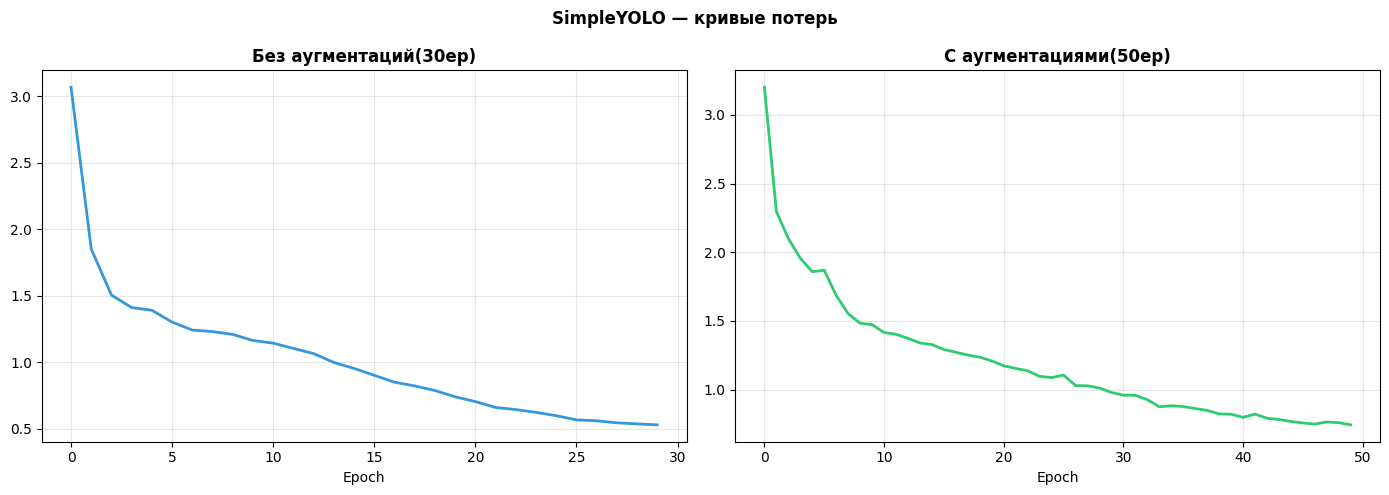

Сохранено: custom_loss.png


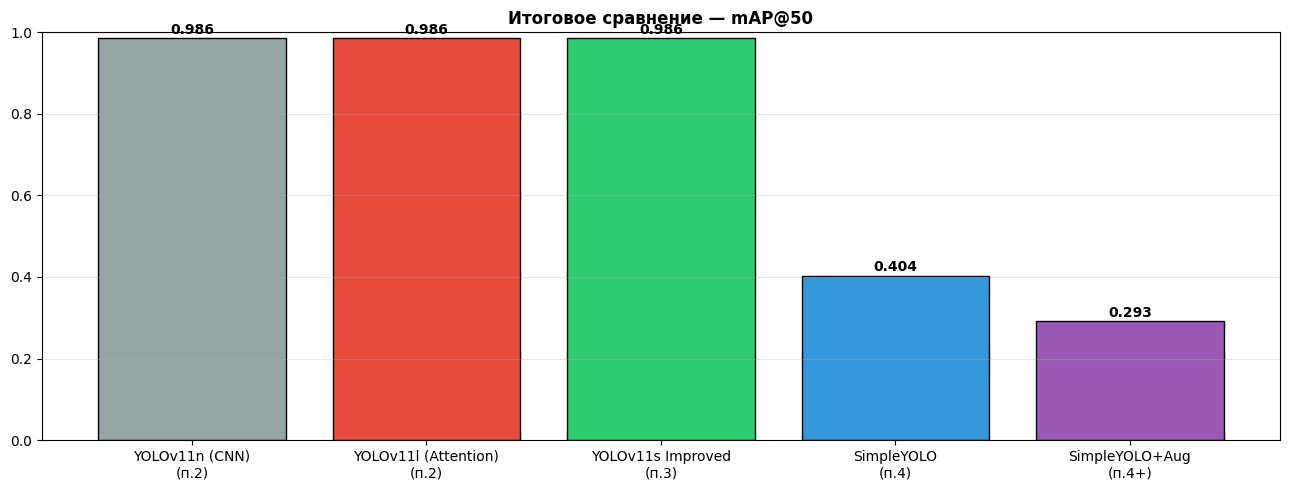

Сохранено: final_comparison.png

4к. ВЫВОДЫ:
SimpleYOLO vs YOLOv11n — разрыв из-за отсутствия pretrain COCO.
SimpleYOLO+Aug vs SimpleYOLO — прирост -0.1109 mAP@50.
Техники п.3 (rotate, AdamW, cosine LR) работают и для кастомной модели.



In [32]:
# 4з. Оценка + финальное сравнение
mi.load_state_dict(torch.load('runs/custom/simple_yolo_improved.pt'))
m50i, apsi = evaluate(mi, vadl, NUM_CLASSES)
print(f'4з. SimpleYOLO+Aug mAP@50: {m50i:.4f}')
for i, n in enumerate(CLASS_NAMES): print(f'  {n}: {apsi[i]:.4f}')

# 4и. Итоговое сравнение
fin = []
if os.path.exists('baseline_results.csv'):
    for _, r in pd.read_csv('baseline_results.csv').iterrows():
        fin.append({'Модель': r['Модель'], 'Пункт': 'п.2', 'mAP@50': r['mAP@50']})
if os.path.exists('improved_results.csv'):
    for _, r in pd.read_csv('improved_results.csv').iterrows():
        if str(r.get('Пункт', '')) == 'п.3':
            fin.append({'Модель': r['Модель'], 'Пункт': 'п.3', 'mAP@50': r['mAP@50']})
fin += [{'Модель': 'SimpleYOLO', 'Пункт': 'п.4', 'mAP@50': round(m50b, 4)},
        {'Модель': 'SimpleYOLO+Aug', 'Пункт': 'п.4+', 'mAP@50': round(m50i, 4)}]
dff = pd.DataFrame(fin)
dff.to_csv('final_results.csv', index=False)
print('\n=== 4и. ИТОГОВОЕ СРАВНЕНИЕ ===')
print(dff.to_string(index=False))

# Графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SimpleYOLO — кривые потерь', fontweight='bold')
for ax, h, ep, c, ttl in zip(axes, [h1, h2], [30, 50], ['#3498DB', '#2ECC71'],
                             ['Без аугментаций', 'С аугментациями']):
    ax.plot(h, color=c, linewidth=2)
    ax.set_title(f'{ttl}({ep}ep)', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('custom_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: custom_loss.png')

pal = ['#95A5A6', '#E74C3C', '#2ECC71', '#3498DB', '#9B59B6']
fig, ax = plt.subplots(figsize=(13, 5))
lbs = [f"{r['Модель']}\n({r['Пункт']})" for _, r in dff.iterrows()]
vs = [float(r['mAP@50']) for _, r in dff.iterrows()]
bars = ax.bar(lbs, vs, color=[pal[i % len(pal)] for i in range(len(vs))], edgecolor='black')
for bar, v in zip(bars, vs): ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center',
                                     fontweight='bold')
ax.set_title('Итоговое сравнение — mAP@50', fontweight='bold', fontsize=12)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: final_comparison.png')

print(f"""
4к. ВЫВОДЫ:
SimpleYOLO vs YOLOv11n — разрыв из-за отсутствия pretrain COCO.
SimpleYOLO+Aug vs SimpleYOLO — прирост {m50i - m50b:+.4f} mAP@50.
Техники п.3 (rotate, AdamW, cosine LR) работают и для кастомной модели.
""")